# `self-footprint` — footprint projection and rolling ball, on the analytic benchmark

The extractor in `Self_ideas/test1_ismail_hoca/weld_seam.py`, run through the Phase 4
harness on the **tier-1 analytic corpus** (`out/bench_phase4`, 720 scenes, 12 strata). No
rendered data is read anywhere in this notebook. It is **not** one of the seven literature
reimplementations (the paper's comparison is closed). It is a candidate for the project's
own extractor, scored with the same metrics on the same strata, so its numbers can sit
next to the seven.

| step (script) | what it does |
|---|---|
| 1 | load, voxel-downsample at the point spacing `v` (all thresholds are multiples of `v`) |
| 2 | optional ICP of the base scan into the assembly (off: the poses are exact here) |
| 3 | segment the assembly: A = what the **base scan** explains, B = the rest |
| 4 | bounded point-to-surface distance fields `D_A`, `D_B` (each part to the other) |
| 5 | footprints `F_A = {p ∈ A : D_A(p) < g}`, `g = 3v + gap` |
| 6 | slide every footprint point along `-∇D` until the distance equals the fit-up gap → root candidates |
| 7 | exposure filter (both parts visible nearby) and clustering on position + groove-opening direction |
| 8 | thin, order (MST longest path), smoothing spline, resample at `2v` |
| 9 | joint frame from the two leg directions → included angle, torch axis, joint class |
| 10 | rolling ball per cross-section → toes, leg lengths, bead area (not scored here) |

**Inputs, and how this harness supplies them.** The method needs two scans: part A
alone (`--base`) and the assembly (`--combined`). The assembly is the harness cloud for the
condition, exactly what every other method gets. A scene has no scan of A alone, so
`baselines.self_footprint.base_scan` synthesises one from the generator's own primitive:
an **independent** area-uniform draw of A at the scene's density (so the two clouds never
share a point and step 3 is not trivially exact), with visibility recomputed with A as the
only occluder (`full_exterior`: the exterior of A alone, `single`: the same camera, A
alone). The faces B later covers are in the base scan, as they are in a real pre-scan.

**No oracle.** The seven literature methods are scored at L0 with their paper's learned
coarse stage replaced by a truth-derived equivalent. This method has no such stage. Its
base scan is a physical input, so its rows carry the L0 label only because they come from
the same chunk definition. Its one process parameter is the expected fit-up gap:
`gap="wps"` passes the scene's root gap (what a welding procedure specification states,
i.e. the method's declared input; the headline), `gap="zero"` is the script's CLI default.

**One refactor of the script**, behaviour-preserving: the body of `run(args)` moved into
`extract(A0, C0, args)`, which takes arrays and returns the paths, and `run` became the file
wrapper around it. The script's own six synthetic scenarios (`test_synthetic.py`) give
byte-identical `seam_paths.csv` before and after.

In [1]:
import sys, pathlib, time, warnings
sys.path.insert(0, ".."); sys.path.insert(0, "../scripts")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import Image, display
from scipy.spatial import cKDTree
warnings.filterwarnings("ignore")
from baselines import prepare, run_matrix, spread
from baselines import self_footprint as sf
import weld_seam as ws

FACTS = pd.read_csv("../out/bench_phase4/facts.csv")
def _fam(r):
    if isinstance(r.seam_family, str): return r.seam_family
    return "line_grooved" if (isinstance(r.prep, str) and r.prep != "square") else "line"
FACTS["family"] = FACTS.apply(_fam, axis=1); FACTS["stratum"] = FACTS.joint_type + "/" + FACTS.family
ORDER_STRATA = ["T/line", "T/circle", "T/ellipse", "T/saddle", "T/rounded_rect", "T/swept_path",
                "corner/line", "butt/line", "butt/line_grooved", "butt/arc_butt", "lap/line", "edge/line"]
ONE = {s: f"../out/bench_phase4/{g.iloc[0].joint_type}/{g.iloc[0].scene_id}" for s, g in FACTS.groupby("stratum")}

METHODS = ["lit-ransac", "lit-regiongrow", "lit-lobb", "lit-ppf", "lit-pcaslice", "lit-modelreg", "lit-quadric", "self-footprint"]
COLOR = dict(zip(METHODS, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]))
GRAY = "#b8b7b2"; INK = "#0b0b0b"; INK2 = "#52514e"
SEQ = LinearSegmentedColormap.from_list("seq", ["#f4f8fd", "#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": "#c9c8c3", "axes.labelcolor": INK2, "xtick.color": INK2,
                     "ytick.color": INK2, "axes.titlesize": 10.5, "axes.titleweight": "bold",
                     "axes.titlecolor": INK, "font.size": 9, "legend.frameon": False,
                     "axes.grid": True, "grid.color": "#ecebe7", "grid.linewidth": 0.6})
FIG = pathlib.Path("../out/self_footprint/figs"); FIG.mkdir(parents=True, exist_ok=True)
print(len(FACTS), "scenes;", FACTS.stratum.value_counts().reindex(ORDER_STRATA).to_dict())

720 scenes; {'T/line': 60, 'T/circle': 60, 'T/ellipse': 60, 'T/saddle': 60, 'T/rounded_rect': 60, 'T/swept_path': 60, 'corner/line': 60, 'butt/line': 60, 'butt/line_grooved': 60, 'butt/arc_butt': 60, 'lap/line': 60, 'edge/line': 60}


## The two inputs — assembly cloud and synthesised base scan

One pipe-on-plate scene. Left: the assembly cloud the harness gives every method (grey =
part A, blue = part B, from `object_id`, shown for orientation only; the method never sees
the labels). Right: the base scan of A alone, an independent draw. In the full-exterior
condition it contains the plate area under the tube; in the single view it is what the same
camera sees of the plate with the tube absent.

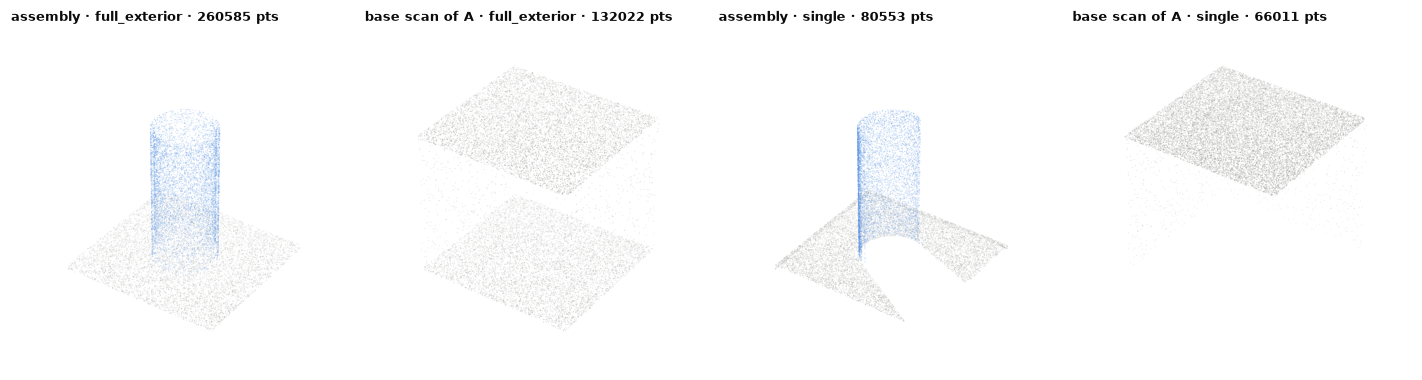

In [2]:
prep = prepare([ONE["T/circle"]])[0]
fig = plt.figure(figsize=(13, 4.6))
for k, view in enumerate(("full_exterior", "single")):
    c = prep.cloud(view, 0.0); A0 = sf.base_scan(prep, view)
    for j, (P, col, title) in enumerate(((c["xyz"], None, f"assembly · {view} · {len(c['xyz'])} pts"),
                                         (A0, "#8a8984", f"base scan of A · {view} · {len(A0)} pts"))):
        ax = fig.add_subplot(1, 4, 2 * k + j + 1, projection="3d")
        st = max(1, len(P) // 15000)
        cc = col or np.where(c["object_id"][::st, None] == 0, [[0.62, 0.62, 0.6]], [[0.34, 0.58, 0.9]])
        ax.scatter(*P[::st].T, s=0.6, c=cc, alpha=0.5, linewidths=0)
        ax.view_init(35, -60); ax.set_title(title, loc="left", fontsize=8.5); ax.set_axis_off()
        ax.set_box_aspect(np.ptp(c["xyz"], axis=0))
plt.tight_layout(); plt.show()

## One scene through the pipeline, in the script's own plots

`weld_seam.make_plots` is the script's own figure: grey = A in the assembly, blue = B, red
= extracted seams, green = torch axis; and the rolling-ball cross-sections. The extra panel
puts the result next to the constructed truth (green) with the footprint candidates of
step 6 (orange) after the exposure filter.

v = 1.03 mm, g = 3.62 mm, ball r = 4.13 mm; footprints A 1429, B 590; root candidates 1603 -> 1602 exposed; 1 path(s)
  S0: fillet   L =  162.3 mm  open  theta ~ 91 deg


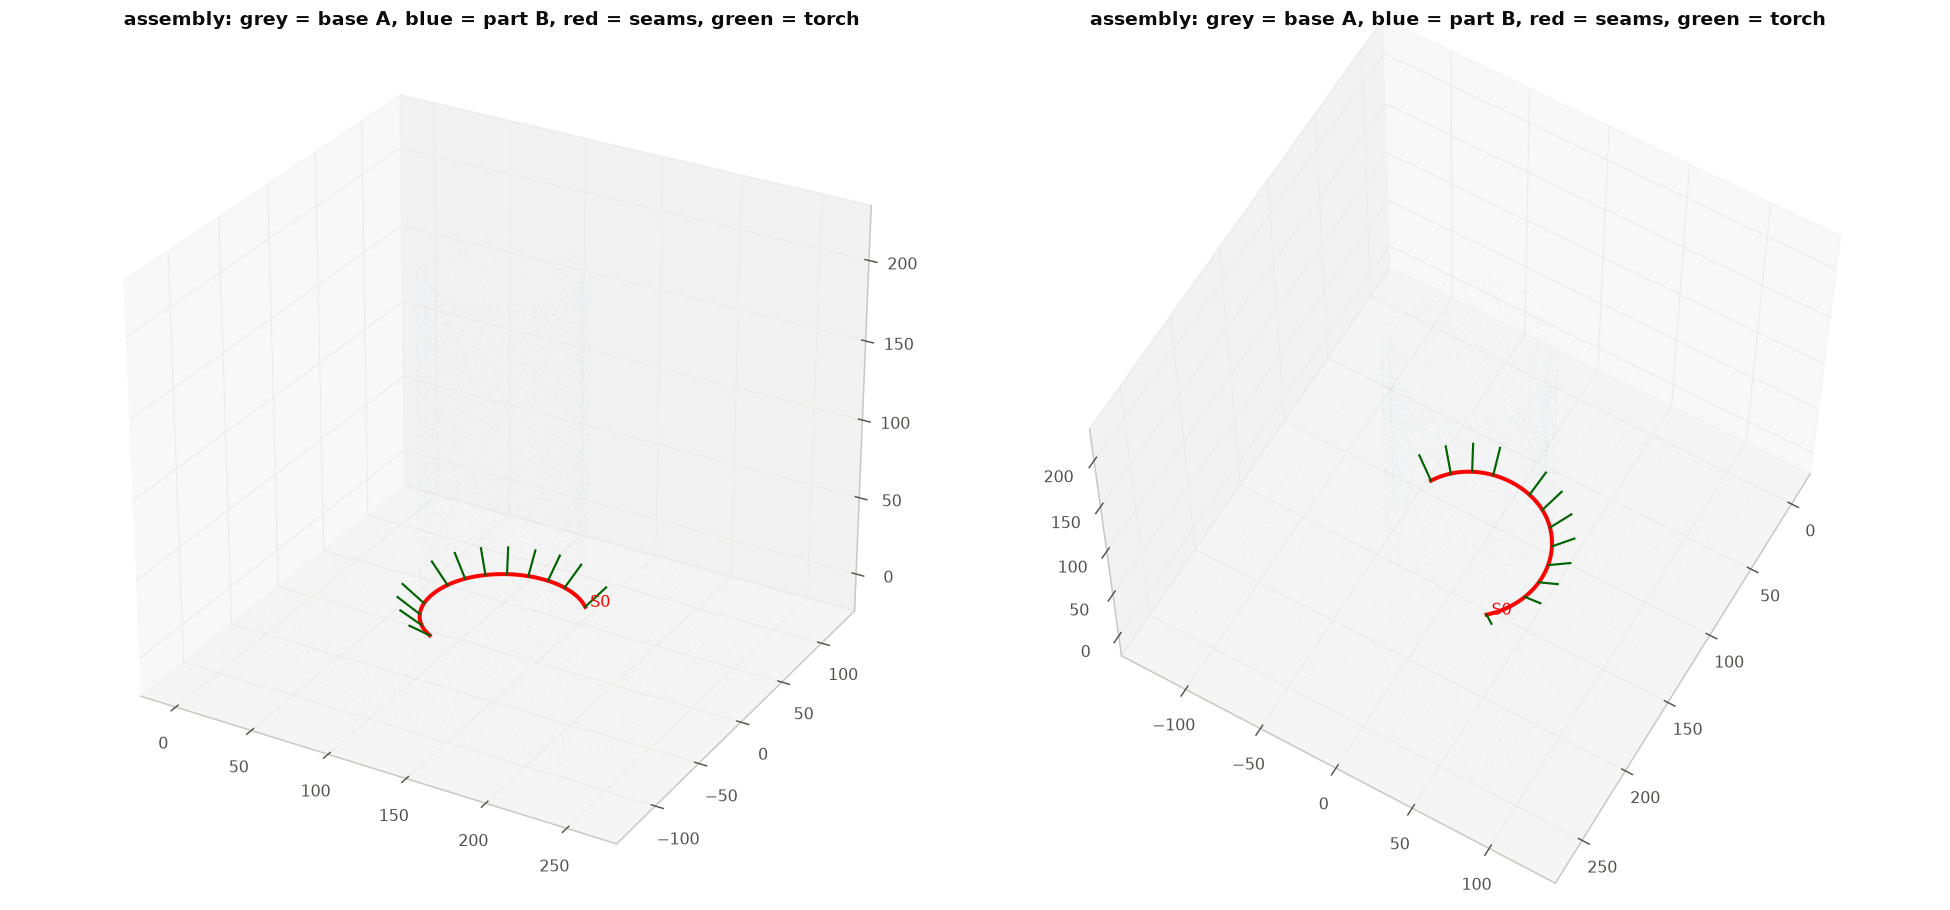

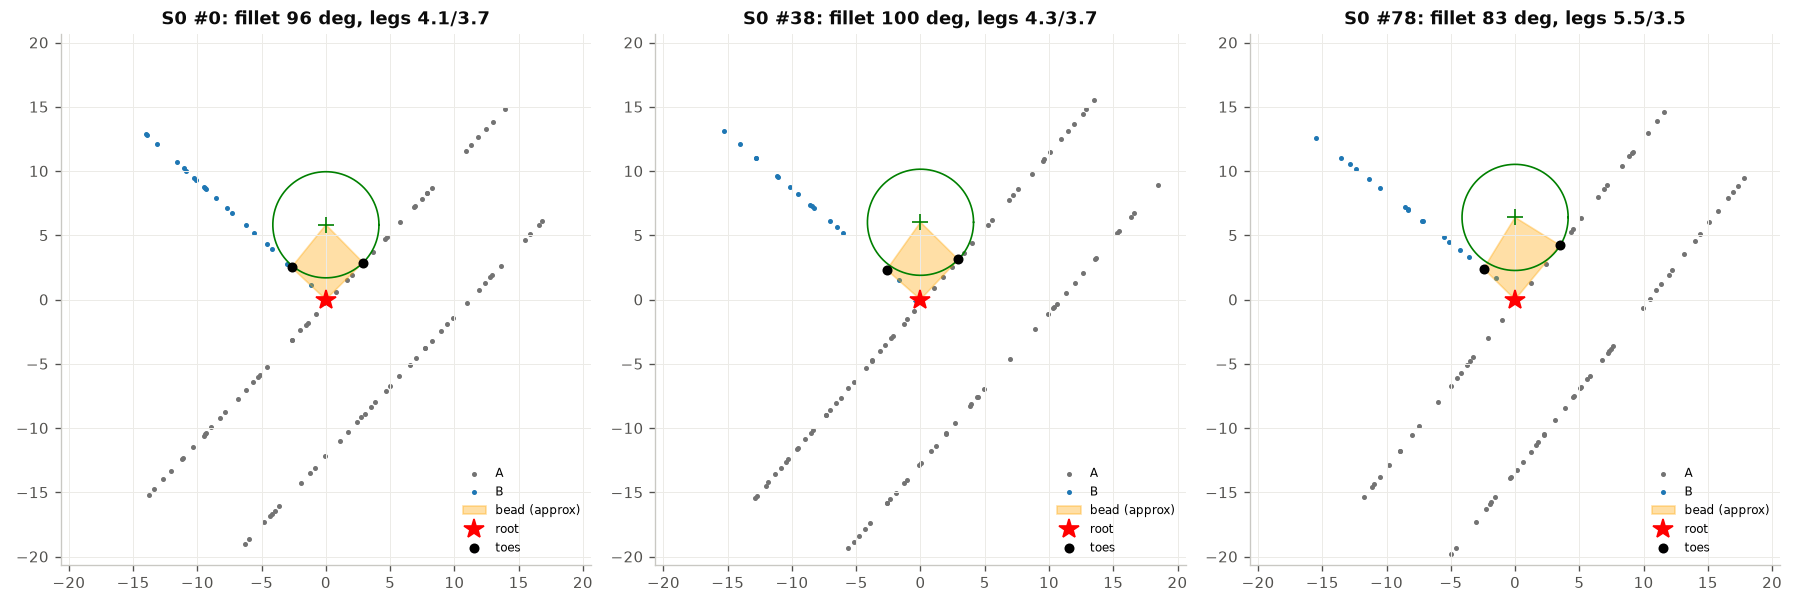

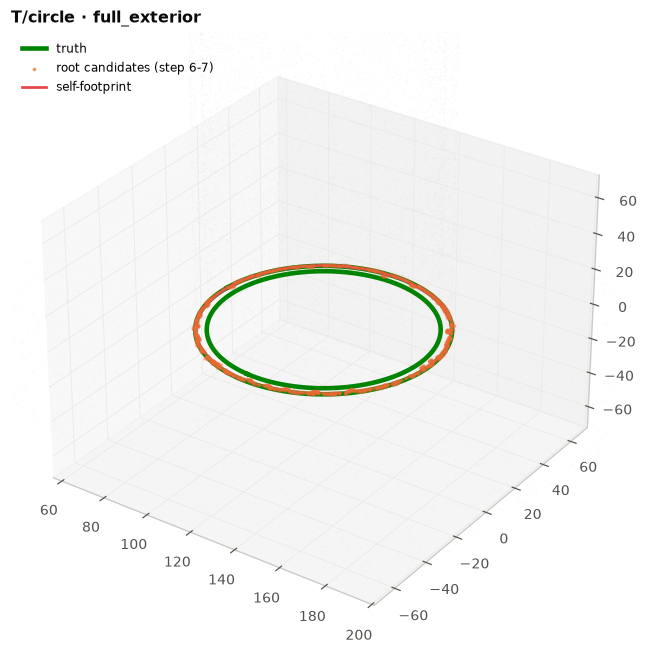

In [3]:
FAM, VIEW = "T/circle", "full_exterior"
prep = prepare([ONE[FAM]])[0]
c = prep.cloud(VIEW, 0.0); A0 = sf.base_scan(prep, VIEW)
polys, r = sf.detect(A0, c["xyz"], gap=float(prep.facts["root_gap_mm"]))
out = FIG / FAM.replace("/", "_"); out.mkdir(exist_ok=True)
ws.make_plots(str(out), r["CA"], r["CB"], r["A"], r["CB"], r["paths"], r["r_ball"], r["v"])
get_ipython().run_line_magic("matplotlib", "inline")      # make_plots switched the backend to Agg
print(f"v = {r['v']:.2f} mm, g = {r['g']:.2f} mm, ball r = {r['r_ball']:.2f} mm; footprints A {int(r['FA'].sum())}, B {int(r['FB'].sum())}; "
      f"root candidates {r['n_raw']} -> {len(r['X'])} exposed; {len(polys)} path(s)")
for i, p in enumerate(r["paths"]):
    s = p["summary"]; print(f"  S{i}: {s['joint_type']:<8s} L = {s['length']:6.1f} mm  {'closed' if s['closed'] else 'open'}  theta ~ {s['theta_median_deg']:.0f} deg")
display(Image(str(out / "overview.png"), width=900))
if (out / "cross_sections.png").exists(): display(Image(str(out / "cross_sections.png"), width=900))

fig = plt.figure(figsize=(7, 6)); ax = fig.add_subplot(111, projection="3d")
st = max(1, len(c["xyz"]) // 20000); ax.scatter(*c["xyz"][::st].T, s=0.6, color="#d5d4cf", alpha=0.4, linewidths=0)
for g in prep.gt: ax.plot(*np.asarray(g).T, color="#008300", linewidth=3, label="truth" if g is prep.gt[0] else None)
ax.scatter(*r["X"].T, s=2, color="#eb6834", alpha=0.6, label="root candidates (step 6-7)")
for i, p in enumerate(polys): ax.plot(*p.T, color=COLOR["self-footprint"], linewidth=1.8, label="self-footprint" if i == 0 else None)
ctr = np.vstack(prep.gt).mean(0); span = 0.5 * np.ptp(np.vstack(prep.gt), axis=0).max() + 25
ax.set_xlim(ctr[0] - span, ctr[0] + span); ax.set_ylim(ctr[1] - span, ctr[1] + span); ax.set_zlim(ctr[2] - span, ctr[2] + span)
ax.view_init(30, -55); ax.legend(fontsize=8, loc="upper left"); ax.set_title(f"{FAM} · {VIEW}", loc="left")
plt.tight_layout(); plt.show()

## Round 1 — one scene per stratum, run live

The first scene of each of the 12 strata, both conditions, the headline `gap="wps"` arm,
two seeds each. The method draws no random number, so the two seeds must agree exactly;
that is checked, not assumed.

In [4]:
rows = []; t0 = time.time()
for st in ORDER_STRATA:
    prep = prepare([ONE[st]])
    for view in ("full_exterior", "single"):
        df = run_matrix(prep, methods=[sf.spec()], seeds=[0, 1], verify_seeds=2, view=view,
                        method_kw={"self-footprint": {"gap": "wps"}})
        df["stratum"] = st; df["condition"] = view; rows.append(df)
R1 = pd.concat(rows, ignore_index=True)
print(f"{len(R1)} rows in {time.time() - t0:.0f}s")
sp = pd.concat([spread(R1[R1.condition == v]) for v in ("full_exterior", "single")])
assert (sp.spread == 0).all(); print(f"zero spread over seeds on all {len(sp)} scene x condition cells: deterministic\n")
t = R1[R1.seed == 0].pivot_table(index="stratum", columns="condition", values=["f1", "precision", "recall", "n_pred_seams"]).reindex(ORDER_STRATA)
print(t.round(2).to_string())

48 rows in 157s
zero spread over seeds on all 24 scene x condition cells: deterministic

                             f1         n_pred_seams            precision               recall       
condition         full_exterior single full_exterior single full_exterior single full_exterior single
stratum                                                                                              
T/line                     0.69   0.77           5.0    1.0          0.91   1.00          0.56   0.63
T/circle                   0.46   0.41           1.0    1.0          1.00   1.00          0.30   0.26
T/ellipse                  0.71   0.34           7.0    2.0          1.00   1.00          0.55   0.20
T/saddle                   1.00   0.31           1.0    1.0          1.00   1.00          1.00   0.19
T/rounded_rect             0.74   0.28           2.0    2.0          0.66   1.00          0.84   0.16
T/swept_path               0.52   0.66           2.0    1.0          1.00   1.00          0.35 

## Round 2 — every scene of every stratum

`scripts/run_self_footprint.py --workers 8` over all 720 scenes (resumable, one CSV per
scene under `out/self_footprint/scenes/`), both conditions, both gap arms, one seed (the
method is deterministic, shown above). Scene-level medians per stratum.

In [5]:
SF = pd.read_csv("../out/self_footprint/self_footprint.csv.gz")
print(f"{len(SF)} rows, {SF.scene_id.nunique()} scenes; failures (Part B empty): {int((SF.failure.fillna('') != '').sum())}")
head = SF[SF.gap == "wps"]
tab = head.pivot_table(index="stratum", columns="condition", values=["f1", "precision", "recall", "rmse_med"], aggfunc="median").reindex(ORDER_STRATA)
tab[("n", "")] = head[head.condition == "full_exterior"].groupby("stratum").size().reindex(ORDER_STRATA)
print("gap = wps (headline), median per stratum"); print(tab.round(2).to_string())

2880 rows, 720 scenes; failures (Part B empty): 16
gap = wps (headline), median per stratum
                             f1            precision               recall             rmse_med          n
condition         full_exterior single full_exterior single full_exterior single full_exterior single    
stratum                                                                                                  
T/line                     0.80   0.60          0.98   1.00          0.68   0.43          0.66   0.60  60
T/circle                   0.80   0.42          1.00   1.00          0.71   0.27          0.41   0.31  60
T/ellipse                  0.78   0.53          1.00   1.00          0.75   0.38          0.40   0.30  60
T/saddle                   1.00   0.66          1.00   1.00          1.00   0.49          0.56   0.39  60
T/rounded_rect             0.78   0.42          0.90   1.00          0.83   0.27          0.38   0.34  60
T/swept_path               0.93   0.61          1.00   1.00 

## Next to the seven — median F1 per stratum

The seven literature methods' coverage chunks from `out/phase4_batch/phase4_batch.csv.gz`
(L0, clean, the same scenes, the same 3 mm tolerance), scene-level medians, and
`self-footprint` (`gap="wps"`) as the eighth row. Read it with the caveat above: the seven
get a truth-derived coarse stage at L0; this method gets a scan of part A alone and nothing
derived from the truth except the WPS gap.

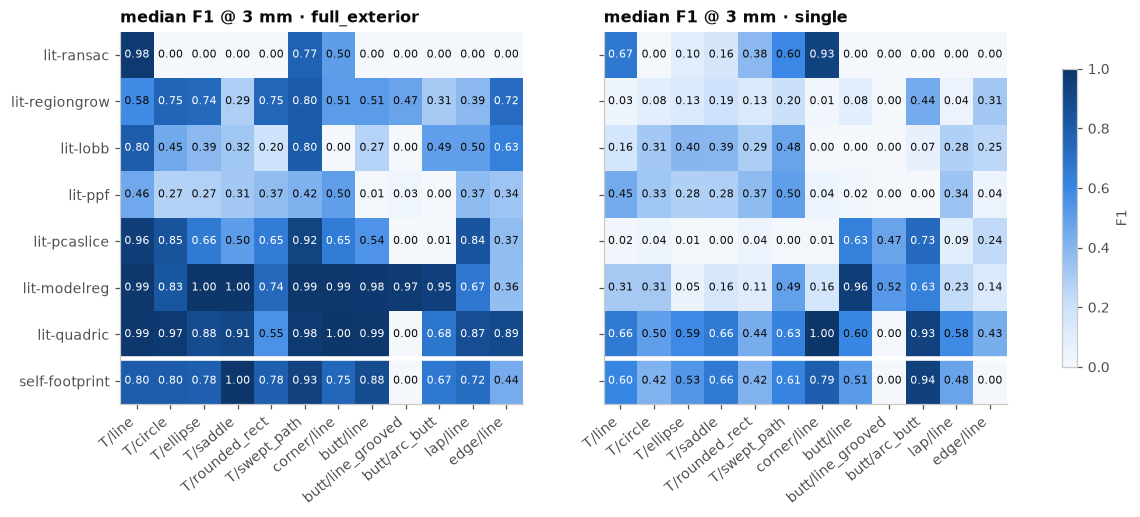

                  self-footprint        best of seven       
condition          full_exterior single full_exterior single
stratum                                                     
T/line                      0.80   0.60          0.99   0.67
T/circle                    0.80   0.42          0.97   0.50
T/ellipse                   0.78   0.53          1.00   0.59
T/saddle                    1.00   0.66          1.00   0.66
T/rounded_rect              0.78   0.42          0.75   0.44
T/swept_path                0.93   0.61          0.99   0.63
corner/line                 0.75   0.79          1.00   1.00
butt/line                   0.88   0.51          0.99   0.96
butt/line_grooved           0.00   0.00          0.97   0.52
butt/arc_butt               0.67   0.94          0.95   0.93
lap/line                    0.72   0.48          0.87   0.58
edge/line                   0.44   0.00          0.89   0.43


In [6]:
DF = pd.read_csv("../out/phase4_batch/phase4_batch.csv.gz", low_memory=False,
                 usecols=["chunk", "method", "scene_id", "condition", "seed", "f1", "precision", "recall", "rmse_med"])
cov = DF[DF.chunk.str.startswith("coverage_")].merge(FACTS[["scene_id", "stratum"]], on="scene_id")
cov = cov.groupby(["method", "condition", "stratum", "scene_id"]).f1.median().reset_index()
mine = head[["method", "condition", "stratum", "scene_id", "f1"]]
ALL = pd.concat([cov, mine], ignore_index=True)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)
for ax, cond in zip(axes, ("full_exterior", "single")):
    M = ALL[ALL.condition == cond].pivot_table(index="method", columns="stratum", values="f1", aggfunc="median").reindex(index=METHODS, columns=ORDER_STRATA)
    im = ax.imshow(M.values, cmap=SEQ, vmin=0, vmax=1, aspect="auto")
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            v = M.values[i, j]
            if np.isfinite(v): ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7, color="white" if v > 0.6 else INK)
    ax.set_xticks(range(len(ORDER_STRATA))); ax.set_xticklabels(ORDER_STRATA, rotation=40, ha="right")
    ax.set_yticks(range(len(METHODS))); ax.set_yticklabels(METHODS); ax.grid(False)
    ax.axhline(len(METHODS) - 1.5, color="white", linewidth=3)
    ax.set_title(f"median F1 @ 3 mm · {cond}", loc="left")
fig.colorbar(im, ax=axes, shrink=0.8, label="F1")
plt.show()
best7 = ALL[(ALL.method != "self-footprint")].groupby(["condition", "stratum", "method"]).f1.median().groupby(["condition", "stratum"]).max()
me = ALL[ALL.method == "self-footprint"].groupby(["condition", "stratum"]).f1.median()
cmp_ = pd.DataFrame({"self-footprint": me, "best of seven": best7}).unstack("condition").reindex(ORDER_STRATA)
print(cmp_.round(2).to_string())

## Path accuracy on matched seams

RMSE of the matched path against constructed truth (the literature's own metric), median per
stratum, full-exterior condition, against the seven's medians on the same strata. A seam
enters only if it was matched, so read this with the recall column above.

In [7]:
rm = DF[DF.chunk.str.startswith("coverage_") & (DF.condition == "full_exterior")].merge(FACTS[["scene_id", "stratum"]], on="scene_id")
rm = rm.groupby(["method", "stratum", "scene_id"]).rmse_med.median().reset_index()
rm = pd.concat([rm, head[head.condition == "full_exterior"][["method", "stratum", "scene_id", "rmse_med"]]])
print(rm.pivot_table(index="stratum", columns="method", values="rmse_med", aggfunc="median").reindex(index=ORDER_STRATA, columns=METHODS).round(2).to_string())

method             lit-ransac  lit-regiongrow  lit-lobb  lit-ppf  lit-pcaslice  lit-modelreg  lit-quadric  self-footprint
stratum                                                                                                                  
T/line                   0.75            2.16      1.08     1.53          2.21          0.70         1.46            0.66
T/circle                 7.13            0.62      2.43     9.78          3.48          2.17         2.53            0.41
T/ellipse               10.36            0.55      1.00     9.22          4.81          1.43         2.27            0.40
T/saddle                12.76            1.53      1.48     1.88          6.43          0.77         1.67            0.56
T/rounded_rect           6.71            0.58      2.15     6.48          4.71          2.79         3.70            0.38
T/swept_path             1.41            0.62      1.44     4.58          4.39          0.71         1.64            0.46
corner/line             

## The gap rung — the method's one input, priced

`gap="zero"` (the CLI default) against `gap="wps"` per stratum, and, for the zero arm, F1
against the scene's actual root gap in units of the footprint threshold. The projection of
step 6 slides a point until its distance to the other part equals the given gap; with the
gap set to zero on a joint with a real gap there is no such point and the candidate is
rejected (`|t| < max_step`, `|f| < tol`).

condition         full_exterior       single      
gap                         wps  zero    wps  zero
stratum                                           
T/line                     0.80  0.58   0.60  0.40
T/circle                   0.80  0.74   0.42  0.28
T/ellipse                  0.78  0.77   0.53  0.38
T/saddle                   1.00  0.84   0.66  0.50
T/rounded_rect             0.78  0.71   0.42  0.32
T/swept_path               0.93  0.79   0.61  0.43
corner/line                0.75  0.00   0.79  0.00
butt/line                  0.88  0.45   0.51  0.00
butt/line_grooved          0.00  0.00   0.00  0.00
butt/arc_butt              0.67  0.61   0.94  0.65
lap/line                   0.72  0.48   0.48  0.23
edge/line                  0.44  0.24   0.00  0.00


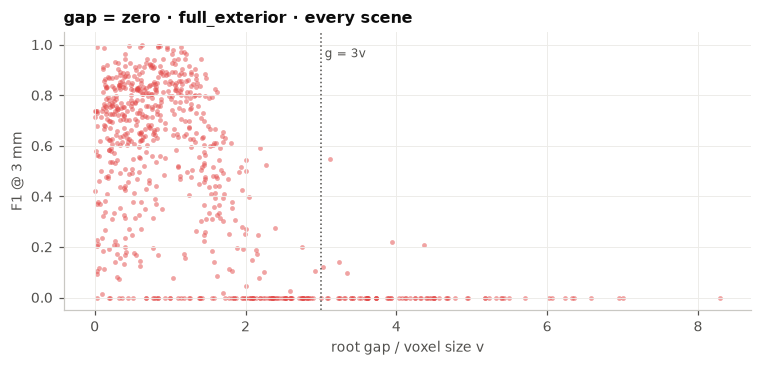

In [8]:
g = SF.pivot_table(index="stratum", columns=["condition", "gap"], values="f1", aggfunc="median").reindex(ORDER_STRATA)
print(g.round(2).to_string())
z = SF[(SF.gap == "zero") & (SF.condition == "full_exterior")].copy()
z["gap_over_v"] = z.root_gap_mm / z.voxel_mm
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.scatter(z.gap_over_v, z.f1, s=10, color=COLOR["self-footprint"], alpha=0.5, linewidths=0)
ax.axvline(3.0, color=INK2, linestyle=":", linewidth=1); ax.text(3.05, 0.95, "g = 3v", color=INK2, fontsize=8)
ax.set_xlabel("root gap / voxel size v"); ax.set_ylabel("F1 @ 3 mm"); ax.set_title("gap = zero · full_exterior · every scene", loc="left")
plt.tight_layout(); plt.show()

## Thin sheets — the footprint threshold against the plate thickness

All thresholds are multiples of the voxel size `v` (the point spacing), and the footprint is
`g = 3v + gap`. The question is whether a part thinner than `g` starves the projection of
step 6: on a lap, the upper plate's edge face is the only B surface next to the root, and it
is only `t` tall. F1 against `t_min / v` on the plate strata, headline arm, one panel per
stratum and condition (dotted: `t_min = 3v`), then the median split at `t_min = 3v`.

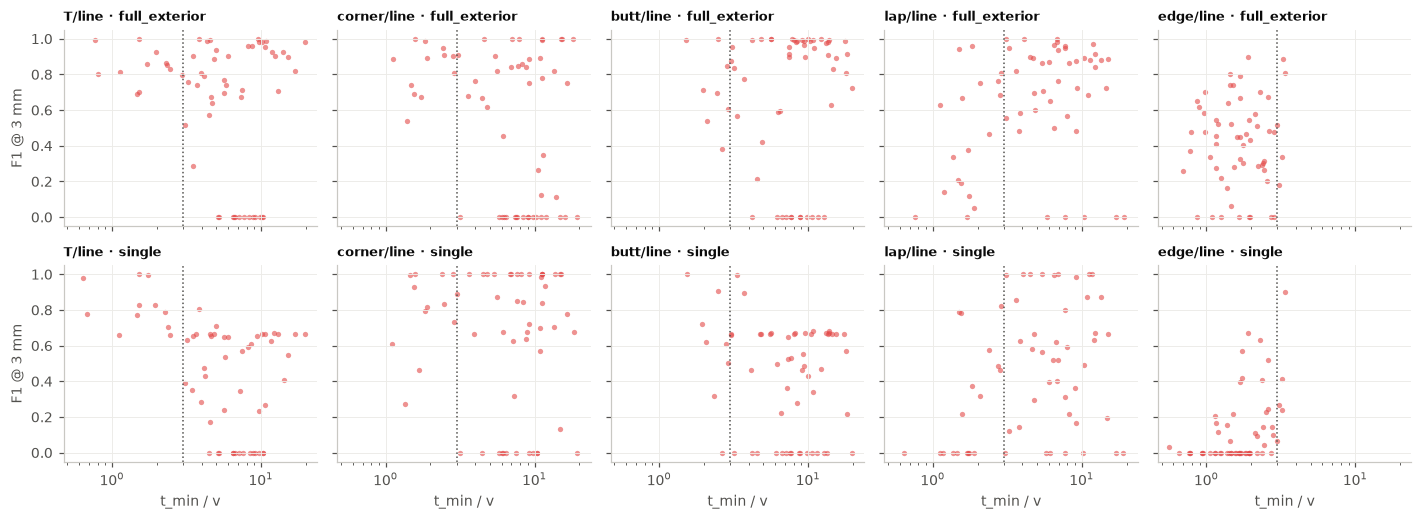

                          median        size      
thin                       False True  False True 
condition     stratum                             
full_exterior T/line        0.75  0.84    48    12
              butt/line     0.90  0.71    52     8
              corner/line   0.64  0.89    48    12
              edge/line     0.34  0.45     5    55
              lap/line      0.85  0.42    42    18
single        T/line        0.43  0.79    49    11
              butt/line     0.49  0.61    52     8
              corner/line   0.71  0.83    48    12
              edge/line     0.25  0.00     6    54
              lap/line      0.57  0.11    42    18


In [9]:
pl = head[head.stratum.isin(["T/line", "corner/line", "butt/line", "lap/line", "edge/line"])].copy()
pl["t_over_v"] = pl.t_min_mm / pl.voxel_mm
PLATES = ["T/line", "corner/line", "butt/line", "lap/line", "edge/line"]
fig, axes = plt.subplots(2, 5, figsize=(13, 4.8), sharex=True, sharey=True)
for i, cond in enumerate(("full_exterior", "single")):
    for j, st in enumerate(PLATES):
        ax = axes[i, j]; q = pl[(pl.condition == cond) & (pl.stratum == st)]
        ax.scatter(q.t_over_v, q.f1, s=12, alpha=0.6, linewidths=0, color=COLOR["self-footprint"])
        ax.axvline(3.0, color=INK2, linestyle=":", linewidth=1)
        ax.set_xscale("log"); ax.set_title(f"{st} · {cond}", loc="left", fontsize=8.5)
        if i == 1: ax.set_xlabel("t_min / v")
    axes[i, 0].set_ylabel("F1 @ 3 mm")
plt.tight_layout(); plt.show()
print(pl.assign(thin=pl.t_over_v < 3).groupby(["condition", "stratum", "thin"]).f1.agg(["median", "size"]).round(2).unstack("thin").to_string())

## Reading it

**Coverage.** Under the perfect multi-view condition, `self-footprint` reaches a median F1 of
0.75–1.00 on 10 of the 12 strata (saddle 1.00, swept path 0.93, butt line 0.88), with precision
at or above 0.85 everywhere except the arc butt (0.50) and the grooved butt. One camera roughly
halves recall (precision stays at 1.00), as it does for every method: half of a ring and the
far side of a plate are out of view.

**Path accuracy is its strength.** On matched seams it has the lowest median RMSE of all eight
entries on 9 of the 12 strata in full view (all six T strata, butt line, arc butt, edge; 0.38–1.15
mm); `lit-lobb` is lower on corner (0.45 vs 0.64) and lap (0.88 vs 0.90), `lit-modelreg` on the
grooved butt.
The mechanism explains it: step 6 slides footprint points until their distance to the other part
equals the fit-up gap, so a root candidate is a measured point on the root edge itself, not an
intersection of two fitted surfaces extrapolated to it.

**Against the seven.** Its F1 is below the best of the seven on most strata (by 0.06–0.45, and by
0.97 on the grooved butt) and ties
or exceeds it on the saddle, the rounded rectangle (0.78 vs 0.75, full view) and the arc butt
(0.94 vs 0.93, single view). The seven are scored at L0 with a truth-derived coarse stage each;
this method gets a scan of part A alone and the WPS gap, nothing derived from the truth.

**Where it fails, and why.**
* *Grooved butt: 0 in both views.* The stored seam is the centreline between the two top faces,
  which an ISO 9692-1 groove holds up to ~25 mm apart: no top-face point is within `g` of the
  other part, so there is no footprint there. What candidates exist come from the groove's root
  faces, a groove depth below the truth (matched RMSE 4.7 mm).
* *Arc butt, full view: precision 0.50.* The truth lists one centreline; the method also returns
  the line on the opposite face of the strips (median 4.5 paths for 1 truth seam). In the single
  view that face is out of sight and F1 is 0.94.
* *Edge joints, single view: 0.* 55 of the 60 edge scenes have plates of 1–2 mm, under `3v`;
  their edge faces are a few samples tall and the single view yields almost no root candidates.
* *Lap joints on thin sheet.* The thickness split confirms the mechanism for laps only: F1 0.85
  → 0.42 (full) and 0.57 → 0.11 (single) when `t_min < 3v`. Thin T and corner joints are not
  hurt (0.84 and 0.89 for thin against 0.75 and 0.64 for thick, full view): their B surface
  next to the root is a broad face, not an edge.

**The gap input is worth most where gaps are large.** With `gap = 0` (the CLI default), corner
joints fall from 0.75 to 0.00 and square butts from 0.88 to 0.45 (single view: 0.51 to 0.00):
the projection looks for a distance of zero that a gapped joint never reaches. The curved T
strata, whose gaps stay at or below 1.2 mm, lose 0.01–0.16.

**Deterministic.** Zero seed spread on every scene-condition cell of the live round; one seed
per cell in the full run. 16 of 2 880 rows are failures, scenes where the segmentation leaves
part B empty or a cloud is near-empty in one condition; they score 0 and are counted.